In [284]:
path = '/train.csv'

In [285]:
import pandas as pd
df = pd.read_csv(path)

In [286]:
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [287]:
nan_col = df.columns[df.isna().any()].tolist()
nan_col

['Name',
 'Monthly_Inhand_Salary',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Credit_History_Age',
 'Amount_invested_monthly',
 'Monthly_Balance']

In [288]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols

['Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Delay_from_due_date',
 'Num_Credit_Inquiries',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month']

In [289]:
cat_col = [col for col in df.columns if col not in num_cols]
cat_col

['ID',
 'Customer_ID',
 'Month',
 'Name',
 'Age',
 'SSN',
 'Occupation',
 'Annual_Income',
 'Num_of_Loan',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'Credit_Score']

<Figure size 800x400 with 0 Axes>

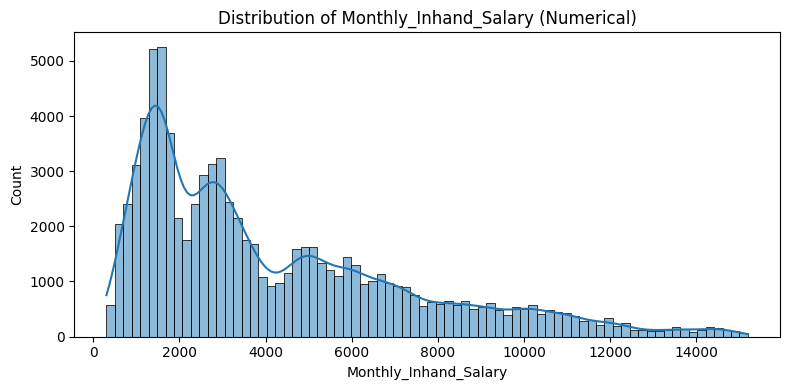

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

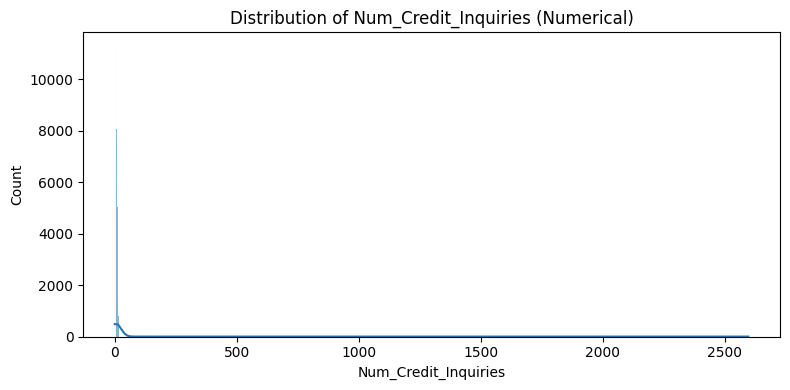

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt


for col in nan_col:
    plt.figure(figsize=(8, 4))
    if col in num_cols:
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col} (Numerical)')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [291]:
df['Monthly_Inhand_Salary'] = df['Monthly_Inhand_Salary'].fillna(df['Monthly_Inhand_Salary'].median())

In [292]:
df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'].fillna(0)

In [293]:
cat_col_w_nans = [col for col in nan_col if col not in num_cols]
cat_col_w_nans

['Name',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Credit_History_Age',
 'Amount_invested_monthly',
 'Monthly_Balance']

In [294]:
df['Monthly_Balance'].sample(3)

,Monthly_Balance
78566,360.66194749518576
81262,268.3681189456691
23173,384.0241302454892


In [295]:
df_nan_rows = df[df[cat_col_w_nans].isna().any(axis=1)]
df_nan_rows[cat_col_w_nans]

,Name,Type_of_Loan,Num_of_Delayed_Payment,Credit_History_Age,Amount_invested_monthly,Monthly_Balance
1,Aaron Maashoh,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,NaN,118.28022162236736,284.62916249607184
4,Aaron Maashoh,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,22 Years and 5 Months,41.420153086217326,341.48923103222177
7,NaN,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,24.785216509052056,358.12416760938714
17,NaN,"Auto Loan, Auto Loan, and Not Specified",6,17 Years and 10 Months,232.86038375993544,998.8692967863226
19,Langep,"Auto Loan, Auto Loan, and Not Specified",5,NaN,825.2162699393922,426.5134106068658
...,...,...,...,...,...,...
99986,NaN,"Personal Loan, Auto Loan, Mortgage Loan, Stude...",25,5 Years and 10 Months,76.28279349064607,345.743101
99990,Sarah McBridec,"Personal Loan, Auto Loan, Mortgage Loan, Stude...",26,NaN,173.2755025599617,228.750392
99992,Nicks,"Auto Loan, and Student Loan",NaN,31 Years and 3 Months,401.1964806036356,189.64108
99993,Nicks,"Auto Loan, and Student Loan",NaN,31 Years and 4 Months,180.7330951944497,400.104466


In [296]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [297]:
col_to_drop = ['ID', 'Customer_ID', 'Name']
for col in col_to_drop:
  df.drop(columns=col, inplace=True)

In [298]:
df.isna().sum()/len(df)

,0
Month,0.00000
Age,0.00000
SSN,0.00000
Occupation,0.00000
Annual_Income,0.00000
Monthly_Inhand_Salary,0.00000
Num_Bank_Accounts,0.00000
Num_Credit_Card,0.00000
Interest_Rate,0.00000
Num_of_Loan,0.00000


In [299]:
# In this investigation, infer that num of delayed payment and amount invest and monthly balance should be converted into numeric
df['Num_of_Delayed_Payment'] = pd.to_numeric(df['Num_of_Delayed_Payment'], errors='coerce')
df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')
df['Monthly_Balance'] = df['Monthly_Balance'].astype(str).str.replace(',', '', regex=False) # In the first warning - mixed types -> in case have floatb
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
draw_list = ['Num_of_Delayed_Payment', 'Monthly_Balance', 'Amount_invested_monthly']

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

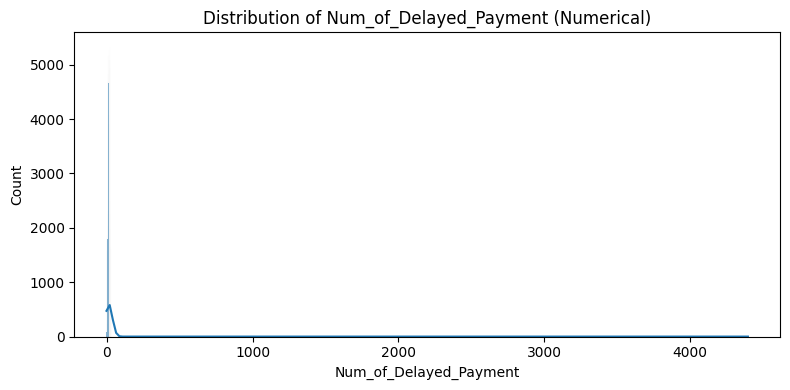

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

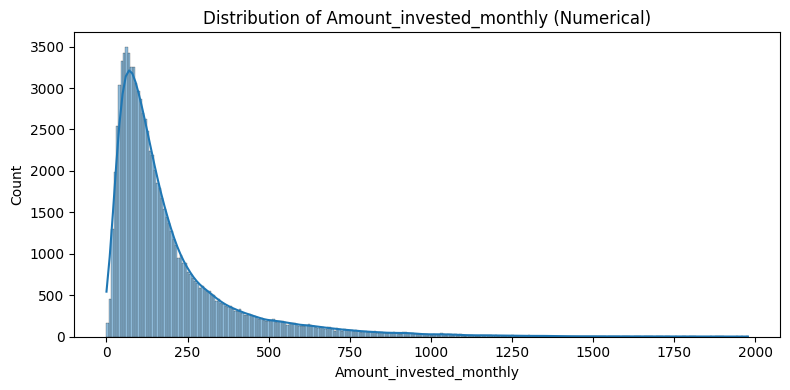

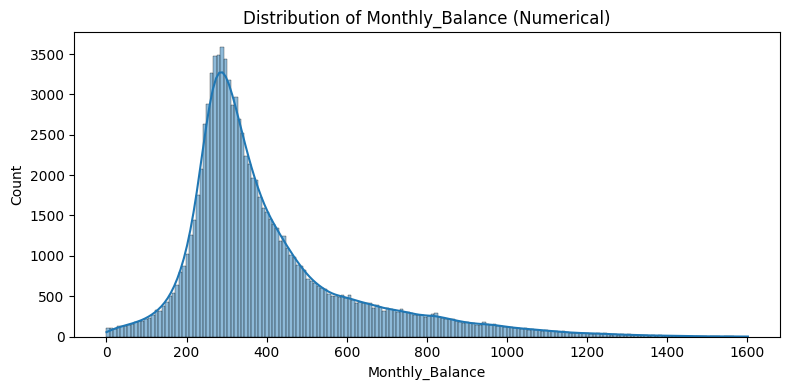

In [300]:
for col in nan_col:
    plt.figure(figsize=(8, 4))
    if col in draw_list:
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col} (Numerical)')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [301]:
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(0)
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(df['Monthly_Balance'].median())
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(df['Amount_invested_monthly'].median())
df.isna().sum()/len(df)

,0
Month,0.00000
Age,0.00000
SSN,0.00000
Occupation,0.00000
Annual_Income,0.00000
Monthly_Inhand_Salary,0.00000
Num_Bank_Accounts,0.00000
Num_Credit_Card,0.00000
Interest_Rate,0.00000
Num_of_Loan,0.00000


In [302]:
df.columns

Index(['Month', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [303]:
def convert_credit_history_age(text):
    try:
        parts = text.split()
        years = int(parts[0])
        months = int(parts[3])
        return years * 12 + months
    except:
        return None

df['Credit_History_Age_Num'] = df['Credit_History_Age'].apply(convert_credit_history_age)

df.drop(columns=['Credit_History_Age'], inplace=True)


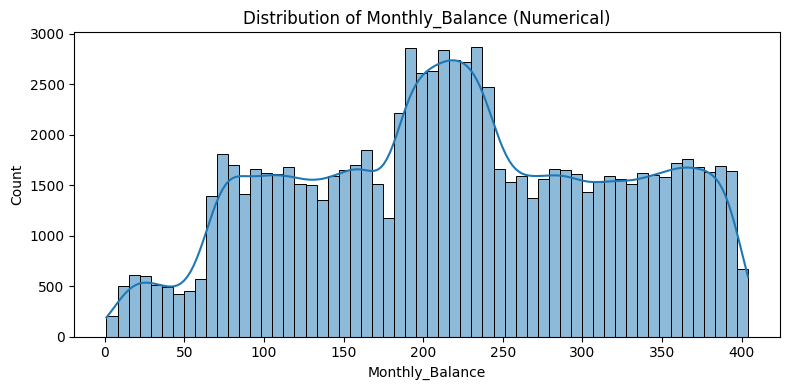

In [304]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Credit_History_Age_Num'], kde=True)
plt.title(f'Distribution of {col} (Numerical)')
plt.xlabel(col)
plt.tight_layout()
plt.show()

In [305]:
df['Credit_History_Age_Num'] = df['Credit_History_Age_Num'].fillna(df['Credit_History_Age_Num'].median())
df = df[~df['Type_of_Loan'].isna()]
df.isna().sum()/len(df)

,0
Month,0.0
Age,0.0
SSN,0.0
Occupation,0.0
Annual_Income,0.0
Monthly_Inhand_Salary,0.0
Num_Bank_Accounts,0.0
Num_Credit_Card,0.0
Interest_Rate,0.0
Num_of_Loan,0.0


In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     88592 non-null  object 
 1   Age                       88592 non-null  object 
 2   SSN                       88592 non-null  object 
 3   Occupation                88592 non-null  object 
 4   Annual_Income             88592 non-null  object 
 5   Monthly_Inhand_Salary     88592 non-null  float64
 6   Num_Bank_Accounts         88592 non-null  int64  
 7   Num_Credit_Card           88592 non-null  int64  
 8   Interest_Rate             88592 non-null  int64  
 9   Num_of_Loan               88592 non-null  object 
 10  Type_of_Loan              88592 non-null  object 
 11  Delay_from_due_date       88592 non-null  int64  
 12  Num_of_Delayed_Payment    88592 non-null  float64
 13  Changed_Credit_Limit      88592 non-null  object 
 14  Num_Credit_

In [307]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols

['Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Credit_History_Age_Num']

In [308]:
cat_col = [col for col in df.columns if col not in num_cols]
cat_col

['Month',
 'Age',
 'SSN',
 'Occupation',
 'Annual_Income',
 'Num_of_Loan',
 'Type_of_Loan',
 'Changed_Credit_Limit',
 'Credit_Mix',
 'Outstanding_Debt',
 'Payment_of_Min_Amount',
 'Payment_Behaviour',
 'Credit_Score']

In [309]:
convert_to_numeric = [
    'Age', 'Annual_Income', 'Num_of_Loan',
    'Changed_Credit_Limit', 'Outstanding_Debt'
]
for col in convert_to_numeric:
  print(df[col])

0          23
1          23
2        -500
3          23
4          23
         ... 
99995      25
99996      25
99997      25
99998      25
99999      25
Name: Age, Length: 88592, dtype: object
0         19114.12
1         19114.12
2         19114.12
3         19114.12
4         19114.12
           ...    
99995     39628.99
99996     39628.99
99997     39628.99
99998     39628.99
99999    39628.99_
Name: Annual_Income, Length: 88592, dtype: object
0        4
1        4
2        4
3        4
4        4
        ..
99995    2
99996    2
99997    2
99998    2
99999    2
Name: Num_of_Loan, Length: 88592, dtype: object
0        11.27
1        11.27
2            _
3         6.27
4        11.27
         ...  
99995     11.5
99996     11.5
99997     11.5
99998     11.5
99999     11.5
Name: Changed_Credit_Limit, Length: 88592, dtype: object
0        809.98
1        809.98
2        809.98
3        809.98
4        809.98
          ...  
99995    502.38
99996    502.38
99997    502.38
99998    502

In [310]:
for col in convert_to_numeric:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.isna().sum()/len(df)

,0
Month,0.000000
Age,0.049181
SSN,0.000000
Occupation,0.000000
Annual_Income,0.069239
Monthly_Inhand_Salary,0.000000
Num_Bank_Accounts,0.000000
Num_Credit_Card,0.000000
Interest_Rate,0.000000
Num_of_Loan,0.047770


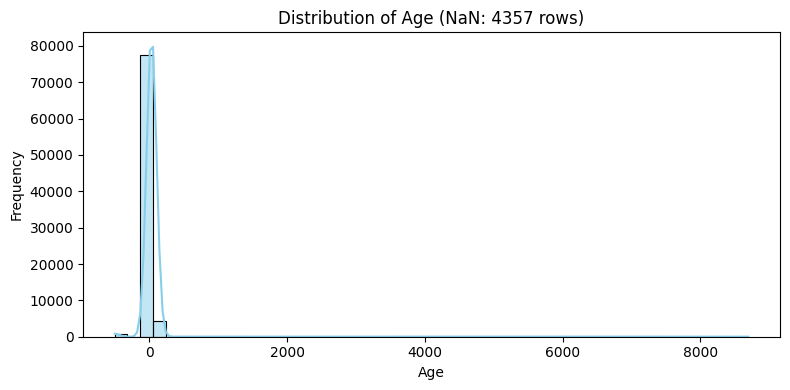

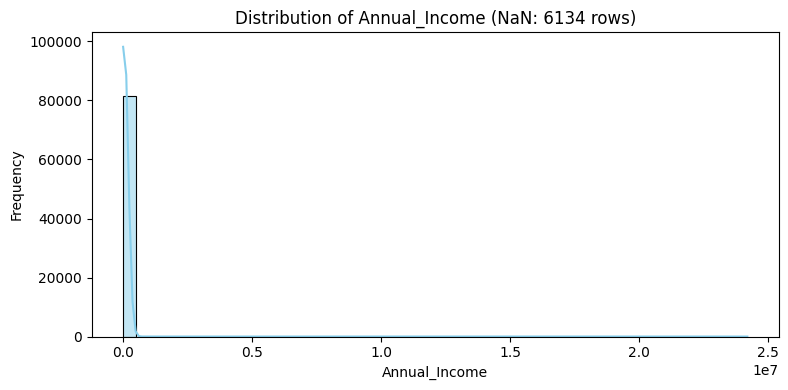

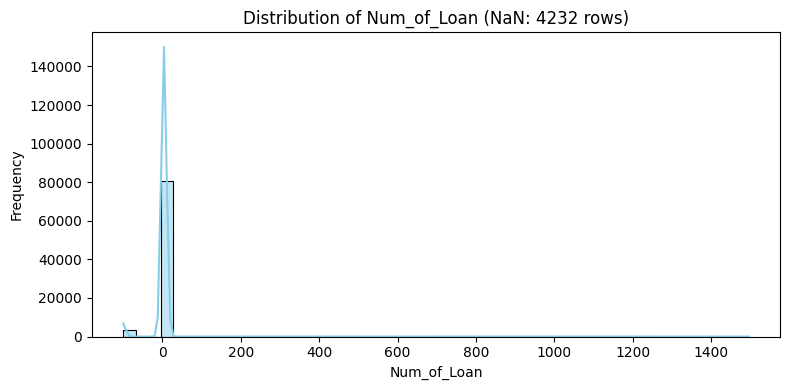

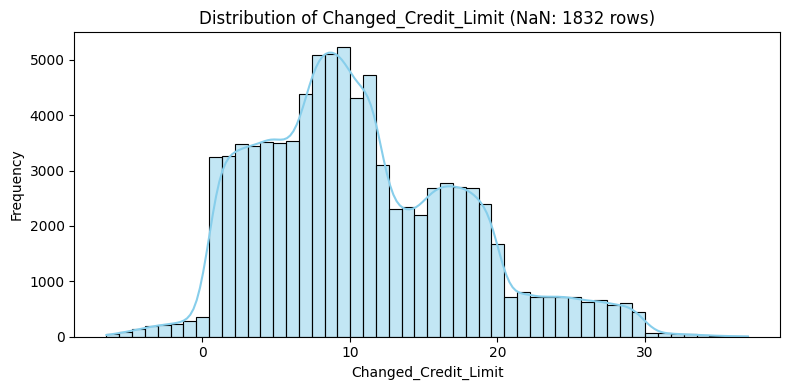

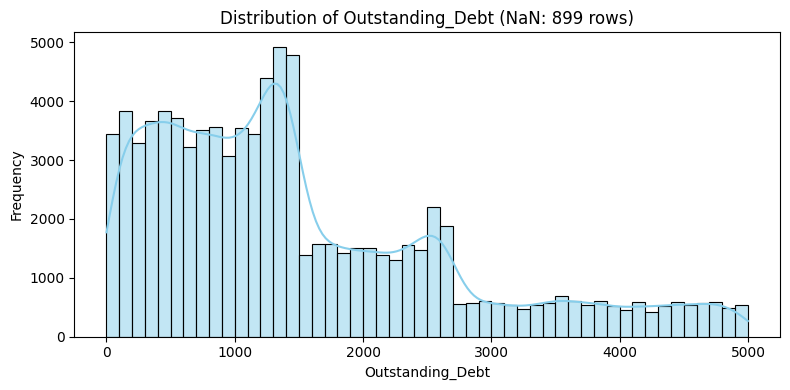

In [311]:
for col in convert_to_numeric:
    if df[col].isna().sum() > 0:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=50, color='skyblue')
        plt.title(f'Distribution of {col} (NaN: {df[col].isna().sum()} rows)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()


In [312]:
col_to_fill_0 = ['Age', 'Num_of_Loan', 'Annual_Income']
df[col_to_fill_0] = df[col_to_fill_0].fillna(0)

col_to_fill_med = ['Changed_Credit_Limit', 'Outstanding_Debt']
df[col_to_fill_med] = df[col_to_fill_med].fillna(df[col_to_fill_med].median())
df.isna().sum()/len(df)

,0
Month,0.0
Age,0.0
SSN,0.0
Occupation,0.0
Annual_Income,0.0
Monthly_Inhand_Salary,0.0
Num_Bank_Accounts,0.0
Num_Credit_Card,0.0
Interest_Rate,0.0
Num_of_Loan,0.0


In [313]:
from sklearn.preprocessing import LabelEncoder

label_encode_cols = ['Payment_of_Min_Amount', 'Credit_Score']

for col in label_encode_cols:
  print(df[col])

le = LabelEncoder()

for col in label_encode_cols:
  df[col] = le.fit_transform(df[col])

0        No
1        No
2        No
3        No
4        No
         ..
99995    No
99996    No
99997    No
99998    No
99999    No
Name: Payment_of_Min_Amount, Length: 88592, dtype: object
0            Good
1            Good
2            Good
3            Good
4            Good
           ...   
99995        Poor
99996        Poor
99997        Poor
99998    Standard
99999        Poor
Name: Credit_Score, Length: 88592, dtype: object


In [314]:
df.isna().sum()/len(df)

,0
Month,0.0
Age,0.0
SSN,0.0
Occupation,0.0
Annual_Income,0.0
Monthly_Inhand_Salary,0.0
Num_Bank_Accounts,0.0
Num_Credit_Card,0.0
Interest_Rate,0.0
Num_of_Loan,0.0


In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     88592 non-null  object 
 1   Age                       88592 non-null  float64
 2   SSN                       88592 non-null  object 
 3   Occupation                88592 non-null  object 
 4   Annual_Income             88592 non-null  float64
 5   Monthly_Inhand_Salary     88592 non-null  float64
 6   Num_Bank_Accounts         88592 non-null  int64  
 7   Num_Credit_Card           88592 non-null  int64  
 8   Interest_Rate             88592 non-null  int64  
 9   Num_of_Loan               88592 non-null  float64
 10  Type_of_Loan              88592 non-null  object 
 11  Delay_from_due_date       88592 non-null  int64  
 12  Num_of_Delayed_Payment    88592 non-null  float64
 13  Changed_Credit_Limit      88592 non-null  float64
 14  Num_Credit_

In [316]:
cat_col = [col for col in cat_col if col not in convert_to_numeric]
cat_col = [col for col in cat_col if col not in label_encode_cols]
cat_col

['Month',
 'SSN',
 'Occupation',
 'Type_of_Loan',
 'Credit_Mix',
 'Payment_Behaviour']

In [317]:
df.drop(columns='SSN', inplace=True)
cat_col.remove('SSN')

In [318]:
for col in cat_col:
  print(f'Columns {col} has {df[col].unique()} unique values')

Columns Month has ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'] unique values
Columns Occupation has ['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Mechanic' 'Writer'
 'Accountant' 'Architect' 'Musician' 'Developer'] unique values
Columns Type_of_Loan has ['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'
 'Credit-Builder Loan' 'Auto Loan, Auto Loan, and Not Specified' ...
 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan'
 'Payday Loan, Student Loan, Mortgage Loan, and Not Specified'
 'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan'] unique values
Columns Credit_Mix has ['_' 'Good' 'Standard' 'Bad'] unique values
Columns Payment_Behaviour has ['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' '!@9#%8'
 'High_spent_Large_valu

In [319]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MultiLabelBinarizer
import pandas as pd

# 1. Occupation: Replace missing or placeholder with 'Unknown', then encode
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')
df['Occupation'] = df['Occupation'].fillna('Unknown')
le_occ = LabelEncoder()
df['Occupation'] = le_occ.fit_transform(df['Occupation'])

# 2. Type_of_Loan → loan_list: Split multiple loans by replacing ' and ' with ',' then split
# Data leakage -> drop
df.drop(columns=['Type_of_Loan'])


# 4. Encode Month using OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
month_encoded = ohe.fit_transform(df[['Month']])
month_encoded_df = pd.DataFrame(month_encoded, columns=ohe.get_feature_names_out(['Month']), index=df.index)

# 5. Merge everything back, drop raw columns
df = pd.concat([
    df.drop(columns=['Month']),
    month_encoded_df
], axis=1)


In [320]:
df.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Credit_History_Age_Num',
       'Month_April', 'Month_August', 'Month_February', 'Month_January',
       'Month_July', 'Month_June', 'Month_March', 'Month_May'],
      dtype='object')

In [321]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       88592 non-null  float64
 1   Occupation                88592 non-null  int64  
 2   Annual_Income             88592 non-null  float64
 3   Monthly_Inhand_Salary     88592 non-null  float64
 4   Num_Bank_Accounts         88592 non-null  int64  
 5   Num_Credit_Card           88592 non-null  int64  
 6   Interest_Rate             88592 non-null  int64  
 7   Num_of_Loan               88592 non-null  float64
 8   Type_of_Loan              88592 non-null  object 
 9   Delay_from_due_date       88592 non-null  int64  
 10  Num_of_Delayed_Payment    88592 non-null  float64
 11  Changed_Credit_Limit      88592 non-null  float64
 12  Num_Credit_Inquiries      88592 non-null  float64
 13  Credit_Mix                88592 non-null  object 
 14  Outstanding

In [322]:
print(df['Payment_Behaviour'])
print(df['Payment_Behaviour'].value_counts(dropna=False))

0         High_spent_Small_value_payments
1          Low_spent_Large_value_payments
2         Low_spent_Medium_value_payments
3          Low_spent_Small_value_payments
4        High_spent_Medium_value_payments
                       ...               
99995     High_spent_Large_value_payments
99996    High_spent_Medium_value_payments
99997     High_spent_Large_value_payments
99998      Low_spent_Large_value_payments
99999                              !@9#%8
Name: Payment_Behaviour, Length: 88592, dtype: object
Payment_Behaviour
Low_spent_Small_value_payments      23156
High_spent_Medium_value_payments    15393
Low_spent_Medium_value_payments     12218
High_spent_Large_value_payments     11833
High_spent_Small_value_payments     10040
Low_spent_Large_value_payments       9240
!@9#%8                               6712
Name: count, dtype: int64


In [323]:
# 6,7k false rows
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Unknown')
le_pb = LabelEncoder()
df['Payment_Behaviour'] = le_pb.fit_transform(df['Payment_Behaviour'])

In [324]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       88592 non-null  float64
 1   Occupation                88592 non-null  int64  
 2   Annual_Income             88592 non-null  float64
 3   Monthly_Inhand_Salary     88592 non-null  float64
 4   Num_Bank_Accounts         88592 non-null  int64  
 5   Num_Credit_Card           88592 non-null  int64  
 6   Interest_Rate             88592 non-null  int64  
 7   Num_of_Loan               88592 non-null  float64
 8   Type_of_Loan              88592 non-null  object 
 9   Delay_from_due_date       88592 non-null  int64  
 10  Num_of_Delayed_Payment    88592 non-null  float64
 11  Changed_Credit_Limit      88592 non-null  float64
 12  Num_Credit_Inquiries      88592 non-null  float64
 13  Credit_Mix                88592 non-null  object 
 14  Outstanding

In [325]:
df['Credit_Mix']

,Credit_Mix
0,_
1,Good
2,Good
3,Good
4,Good
...,...
99995,_
99996,_
99997,Good
99998,Good


In [326]:
df = df[df['Credit_Mix'] != '_']


# Training Process

In [333]:
# Encode label (Credit_Mix) riêng
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Credit_Mix'])
cols_to_drop = [
    'Credit_Score',
    'Payment_Behaviour', 'Type_of_Loan',
    'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount'
]
X = df.drop(columns=cols_to_drop)
# Tạo feature matrix X
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [334]:
X.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_History_Age_Num', 'Month_April', 'Month_August',
       'Month_February', 'Month_January', 'Month_July', 'Month_June',
       'Month_March', 'Month_May'],
      dtype='object')

In [337]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70805 entries, 1 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       70805 non-null  float64
 1   Annual_Income             70805 non-null  float64
 2   Monthly_Inhand_Salary     70805 non-null  float64
 3   Num_Bank_Accounts         70805 non-null  int64  
 4   Num_Credit_Card           70805 non-null  int64  
 5   Interest_Rate             70805 non-null  int64  
 6   Num_of_Loan               70805 non-null  float64
 7   Delay_from_due_date       70805 non-null  int64  
 8   Num_of_Delayed_Payment    70805 non-null  float64
 9   Changed_Credit_Limit      70805 non-null  float64
 10  Num_Credit_Inquiries      70805 non-null  float64
 11  Outstanding_Debt          70805 non-null  float64
 12  Credit_Utilization_Ratio  70805 non-null  float64
 13  Total_EMI_per_month       70805 non-null  float64
 14  Amount_inve

In [335]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

from xgboost import XGBClassifier
model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    verbosity=0
)
model.fit(X_train, y_train)

from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      3798
        Poor       0.98      0.97      0.97      3865
    Standard       0.97      0.98      0.97      6498

    accuracy                           0.98     14161
   macro avg       0.98      0.98      0.98     14161
weighted avg       0.98      0.98      0.98     14161

